

---



# Modelo predictivo para la estimación del riesgo y la severidad de incendios forestales basado en datos meteorológicos e históricos mediante algoritmos de aprendizaje automático supervisado

## 0 Fichero de datos 
https://www.kaggle.com/datasets/capcloudcoder/us-wildfire-data-plus-other-attributes

# 1. Importar librerías para EDA

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)



---



# 2. Carga de datos del csv en único data frame.

In [3]:
#cargar el csv FW_Veg_Rem_Combined
df = pd.read_csv(r'DataSets\FW_Veg_Rem_Combined.csv', low_memory=False)            


# 3 Exploración de los  datos 

### 3.1 Mostrar las cinco primeras filas

In [4]:
df.head(5)

,Unnamed: 0.1,Unnamed: 0,fire_name,fire_size,fire_size_class,stat_cause_descr,latitude,longitude,state,disc_clean_date,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
0,0,0,NaN,10.0,C,Missing/Undefined,18.105072,-66.753044,PR,2/11/2007,...,3.250413,78.216590,76.793750,76.381579,78.724370,0.0,0.0,0.0,0.0,0.017923
1,1,1,NaN,3.0,B,Arson,35.038330,-87.610000,TN,12/11/2006,...,2.122320,70.840000,65.858911,55.505882,81.682678,59.8,8.4,0.0,86.8,0.184355
2,2,2,NaN,60.0,C,Arson,34.947800,-88.722500,MS,2/29/2004,...,3.369050,75.531629,75.868613,76.812834,65.063800,168.8,42.2,18.1,124.5,0.194544
3,3,3,WNA 1,1.0,B,Debris Burning,39.641400,-119.308300,NV,6/6/2005,...,0.000000,44.778429,37.140811,35.353846,0.000000,10.4,7.2,0.0,0.0,0.487447
4,4,4,NaN,2.0,B,Miscellaneous,30.700600,-90.591400,LA,9/22/1999,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.214633


### 3.2 Mostrar las cinco últimas filas

In [5]:
df.tail(5)                        # To display the botton 5 rows

,Unnamed: 0.1,Unnamed: 0,fire_name,fire_size,fire_size_class,stat_cause_descr,latitude,longitude,state,disc_clean_date,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
55362,55362,55362,IMPACT,6289.0,G,Missing/Undefined,39.180000,-96.784167,KS,10/15/2015,...,3.804803,65.671410,61.839572,54.625698,55.042092,35.4,8.2,0.0,249.0,0.331501
55363,55363,55363,BUTTE,70868.0,G,Missing/Undefined,38.342719,-120.695967,CA,9/9/2015,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.124683
55364,55364,55364,WILLOW,5702.0,G,Arson,37.262607,-119.511139,CA,7/25/2015,...,2.529158,43.755556,43.755556,44.443975,35.924406,0.0,0.0,0.0,0.0,0.097682
55365,55365,55365,BARKER,3261.0,F,Miscellaneous,40.604300,-123.080450,CA,7/31/2015,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.178206
55366,55366,55366,VALLEY,76067.0,G,Missing/Undefined,38.843988,-122.759707,CA,9/12/2015,...,1.208073,50.521912,46.310627,37.178571,58.063802,0.3,0.3,0.0,18.8,0.167305




---



### 3.3 Mostrar columnas del data set

In [6]:
print(df.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'fire_name', 'fire_size',
       'fire_size_class', 'stat_cause_descr', 'latitude', 'longitude', 'state',
       'disc_clean_date', 'cont_clean_date', 'discovery_month',
       'disc_date_final', 'cont_date_final', 'putout_time', 'disc_date_pre',
       'disc_pre_year', 'disc_pre_month', 'wstation_usaf', 'dstation_m',
       'wstation_wban', 'wstation_byear', 'wstation_eyear', 'Vegetation',
       'fire_mag', 'weather_file', 'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7',
       'Temp_cont', 'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7', 'Wind_cont',
       'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7', 'Hum_cont', 'Prec_pre_30',
       'Prec_pre_15', 'Prec_pre_7', 'Prec_cont', 'remoteness'],
      dtype='object')


### 3.4 Mostrar la forma del DataFrame

In [7]:
print(df.shape)

(55367, 43)


###  3.5 Comprobar la información del DataFrame

In [8]:
df .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55367 entries, 0 to 55366
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      55367 non-null  int64  
 1   Unnamed: 0        55367 non-null  int64  
 2   fire_name         25913 non-null  object 
 3   fire_size         55367 non-null  float64
 4   fire_size_class   55367 non-null  object 
 5   stat_cause_descr  55367 non-null  object 
 6   latitude          55367 non-null  float64
 7   longitude         55367 non-null  float64
 8   state             55367 non-null  object 
 9   disc_clean_date   55367 non-null  object 
 10  cont_clean_date   27477 non-null  object 
 11  discovery_month   55367 non-null  object 
 12  disc_date_final   28708 non-null  object 
 13  cont_date_final   25632 non-null  object 
 14  putout_time       27477 non-null  object 
 15  disc_date_pre     55367 non-null  object 
 16  disc_pre_year     55367 non-null  int64 

### 3.6 Mostrar las estadísticas descriptivas

In [9]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,fire_size,latitude,longitude,disc_pre_year,dstation_m,wstation_wban,wstation_byear,wstation_eyear,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
count,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,...,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000
mean,27683.000000,27683.000000,2104.645161,36.172866,-94.757971,2003.765474,40256.474678,61029.607311,1979.341900,2015.480990,...,1.132284,40.781796,38.453935,37.001865,25.056738,26.277046,11.654253,4.689920,15.590440,0.236799
std,15983.220514,15983.220514,14777.005364,6.724348,15.878194,6.584889,25272.081410,40830.393541,23.372803,6.767851,...,2.030611,31.086856,31.042541,30.827885,31.187638,112.050198,56.920510,31.205327,59.757113,0.144865
min,0.000000,0.000000,0.510000,17.956533,-165.936000,1991.000000,6.166452,100.000000,1931.000000,1993.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,13841.500000,13841.500000,1.200000,32.265960,-102.541513,1999.000000,21373.361515,13927.000000,1973.000000,2010.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.137800
50%,27683.000000,27683.000000,4.000000,34.600000,-91.212359,2005.000000,35621.334820,73803.000000,1978.000000,2020.000000,...,0.000000,55.657480,51.753846,48.230769,0.000000,0.000000,0.000000,0.000000,0.000000,0.202114
75%,41524.500000,41524.500000,20.000000,38.975235,-82.847500,2009.000000,53985.904315,99999.000000,2004.000000,2020.000000,...,2.848603,67.384352,65.911469,64.645296,60.193606,18.900000,3.600000,0.000000,0.000000,0.284782
max,55366.000000,55366.000000,606945.000000,69.849500,-65.285833,2015.000000,224153.661800,99999.000000,2014.000000,2020.000000,...,24.200000,96.000000,94.000000,96.000000,94.000000,13560.800000,2527.000000,1638.000000,2126.000000,1.000000


### Filtrar las columnas relevantes

In [10]:
#df = df.drop(['cont_clean_date'], axis=1)
#df.head(5)

### 3.7 Renombrar las columnas 

In [11]:
df = df.rename(columns = {'Unnamed': '0.1', 
                          'Unnamed': '0',
                            'fire_name': 'Name of Fire',
                            'fire_size': 'Size of Fire',
                            'fire_size_class': 'Class of Fire Size (A-G)', 
                            'stat_cause_descr': 'Cause of Fire', 
                            'latitude': 'Latitude of Fire', 
                            'longitude': 'Longitude of Fire', 
                            'state': 'State of Fire',
                            'disc_clean_date': 'Discovery Date', 
                            'cont_clean_date': 'Containment Date', 
                            'discovery_month': 'Month of Discovery',
                            'disc_date_final': 'Final Discovery Date', 
                            'cont_date_final': 'Final Containment Date', 
                            'putout_time': 'Time to Put Out Fire', 
                            'disc_date_pre': 'Preliminary Discovery Date',
                            'disc_pre_year': 'Year of Preliminary Discovery', 
                            'disc_pre_month': 'Month of Preliminary Discovery', 
                            'wstation_usaf': 'Weather Station USAF', 'dstation_m': 'Distance to Station M',
                            'wstation_wban': 'Weather Station WBAN', 
                            'wstation_byear': 'Weather Station Begin Year', 
                            'wstation_eyear': 'Weather Station End Year',
                            'Vegetation': 'Dominant Vegetation',
                            'fire_mag': 'Magnitude of Fire',
                            'weather_file': 'Weather File', 
                            'Temp_pre_30': 'Temperature 30 Days Prior', 
                            'Temp_pre_15': 'Temperature 15 Days Prior', 
                            'Temp_pre_7': 'Temperature 7 Days Prior',
                            'Temp_cont': 'Temperature on Containment Day', 
                            'Wind_pre_30': 'Wind 30 Days Prior', 
                            'Wind_pre_15': 'Wind 15 Days Prior',
                            'Wind_pre_7': 'Wind 7 Days Prior', 
                            'Wind_cont': 'Wind on Containment Day',
                            'Hum_pre_30': 'Humidity 30 Days Prior',
                            'Hum_pre_15': 'Humidity 15 Days Prior', 
                            'Hum_pre_7': 'Humidity 7 Days Prior', 
                            'Hum_cont': 'Humidity on Containment Day', 
                            'Prec_pre_30': 'Precipitation 30 Days Prior',
                            'Prec_pre_15': 'Precipitation 15 Days Prior', 
                            'Prec_pre_7': 'Precipitation 7 Days Prior', 
                            'Prec_cont': 'Precipitation on Containment Day', 
                            'remoteness': 'Remoteness'})

df.head(5)

,Unnamed: 0.1,Unnamed: 0,Name of Fire,Size of Fire,Class of Fire Size (A-G),Cause of Fire,Latitude of Fire,Longitude of Fire,State of Fire,Discovery Date,...,Wind on Containment Day,Humidity 30 Days Prior,Humidity 15 Days Prior,Humidity 7 Days Prior,Humidity on Containment Day,Precipitation 30 Days Prior,Precipitation 15 Days Prior,Precipitation 7 Days Prior,Precipitation on Containment Day,Remoteness
0,0,0,NaN,10.0,C,Missing/Undefined,18.105072,-66.753044,PR,2/11/2007,...,3.250413,78.216590,76.793750,76.381579,78.724370,0.0,0.0,0.0,0.0,0.017923
1,1,1,NaN,3.0,B,Arson,35.038330,-87.610000,TN,12/11/2006,...,2.122320,70.840000,65.858911,55.505882,81.682678,59.8,8.4,0.0,86.8,0.184355
2,2,2,NaN,60.0,C,Arson,34.947800,-88.722500,MS,2/29/2004,...,3.369050,75.531629,75.868613,76.812834,65.063800,168.8,42.2,18.1,124.5,0.194544
3,3,3,WNA 1,1.0,B,Debris Burning,39.641400,-119.308300,NV,6/6/2005,...,0.000000,44.778429,37.140811,35.353846,0.000000,10.4,7.2,0.0,0.0,0.487447
4,4,4,NaN,2.0,B,Miscellaneous,30.700600,-90.591400,LA,9/22/1999,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.214633


### 3.8 Tipos de datos

In [12]:
df.dtypes

Unnamed: 0.1                          int64
Unnamed: 0                            int64
Name of Fire                         object
Size of Fire                        float64
Class of Fire Size (A-G)             object
Cause of Fire                        object
Latitude of Fire                    float64
Longitude of Fire                   float64
State of Fire                        object
Discovery Date                       object
Containment Date                     object
Month of Discovery                   object
Final Discovery Date                 object
Final Containment Date               object
Time to Put Out Fire                 object
Preliminary Discovery Date           object
Year of Preliminary Discovery         int64
Month of Preliminary Discovery       object
Weather Station USAF                 object
Distance to Station M               float64
Weather Station WBAN                  int64
Weather Station Begin Year            int64
Weather Station End Year        



---



### 3.9 Identificar columnas con valores nulos

In [13]:
df_null = df.isna()
#Count of missing values in each column
df_null.sum()


Unnamed: 0.1                            0
Unnamed: 0                              0
Name of Fire                        29454
Size of Fire                            0
Class of Fire Size (A-G)                0
Cause of Fire                           0
Latitude of Fire                        0
Longitude of Fire                       0
State of Fire                           0
Discovery Date                          0
Containment Date                    27890
Month of Discovery                      0
Final Discovery Date                26659
Final Containment Date              29735
Time to Put Out Fire                27890
Preliminary Discovery Date              0
Year of Preliminary Discovery           0
Month of Preliminary Discovery          0
Weather Station USAF                    0
Distance to Station M                   0
Weather Station WBAN                    0
Weather Station Begin Year              0
Weather Station End Year                0
Dominant Vegetation               

### 3.10 Eliminar valores faltantes

In [14]:
#df = df.dropna()
#df


### 3.11 Eliminar filas duplicadas

In [15]:
duplicate_rows_df = df.duplicated()
duplicate_rows_df
print("número de filas duplicadas: ", duplicate_rows_df.sum())

número de filas duplicadas:  0


### 3.12 Exploración visual de variables.

#### 3.12.1 Detectar valores atípicos gráfico de cajas 

In [16]:
#Quiero usar el seaborn Box Plot para todas las columnas numéricas del dataframe para detectar outliers, usar leyendas . Para ello, primero identificaremos las columnas numéricas y luego generaremos un boxplot para cada una de ellas. Aquí tienes un ejemplo de cómo hacerlo:      
import seaborn as sns
import matplotlib.pyplot as plt

# numeric_columns = df.select_dtypes(include=['number']).columns  # Exclude latitude and longitude if not needed
# for col in numeric_columns:    
#     if col.startswith('Unnamed'):
#         continue
#     sns.boxplot(x=df[col])
#     plt.title(f'Boxplot of {col}')
#     plt.show()


#### 3.12.2 Detectar valores atípicos gráfico de relaciones 

In [17]:

#usar sns.Scatter Plot para relacionar variables numéricas del dataframe, usar leyendas. Aquí tienes un ejemplo de cómo hacerlo:
import seaborn as sns
import matplotlib.pyplot as plt

# numeric_columns = df.select_dtypes(include=['number']).columns  # Exclude latitude and longitude if not needed
# for i, col1 in enumerate(numeric_columns):
#     if col1.startswith('Unnamed'):
#         continue
#     for col2 in numeric_columns[i+1:]:
#         if col2.startswith('Unnamed'):
#             continue
#         sns.scatterplot(x=df[col1], y=df[col2], hue=df['Magnitude of Fire'])
#         plt.title(f'Scatter Plot of {col1} vs {col2}')
#         plt.show()
        

#### 3.12.3 Detectar valores atípicos con la métrica z-score

Filas originales: 55367
Filas sin outliers: 48988
Cantidad de outliers por columna:
Size of Fire                         537
Distance to Station M                597
Magnitude of Fire                   3972
Temperature 30 Days Prior              3
Temperature 15 Days Prior              3
Temperature 7 Days Prior               3
Temperature on Containment Day         6
Wind 30 Days Prior                    44
Wind 15 Days Prior                    39
Wind 7 Days Prior                     60
Wind on Containment Day              195
Precipitation 30 Days Prior          448
Precipitation 15 Days Prior          461
Precipitation 7 Days Prior           365
Precipitation on Containment Day     870
Remoteness                           861
dtype: int64

Porcentaje de outliers por columna:
Size of Fire                        0.97%
Distance to Station M               1.08%
Magnitude of Fire                   7.17%
Temperature 30 Days Prior           0.01%
Temperature 15 Days Prior           0.01%


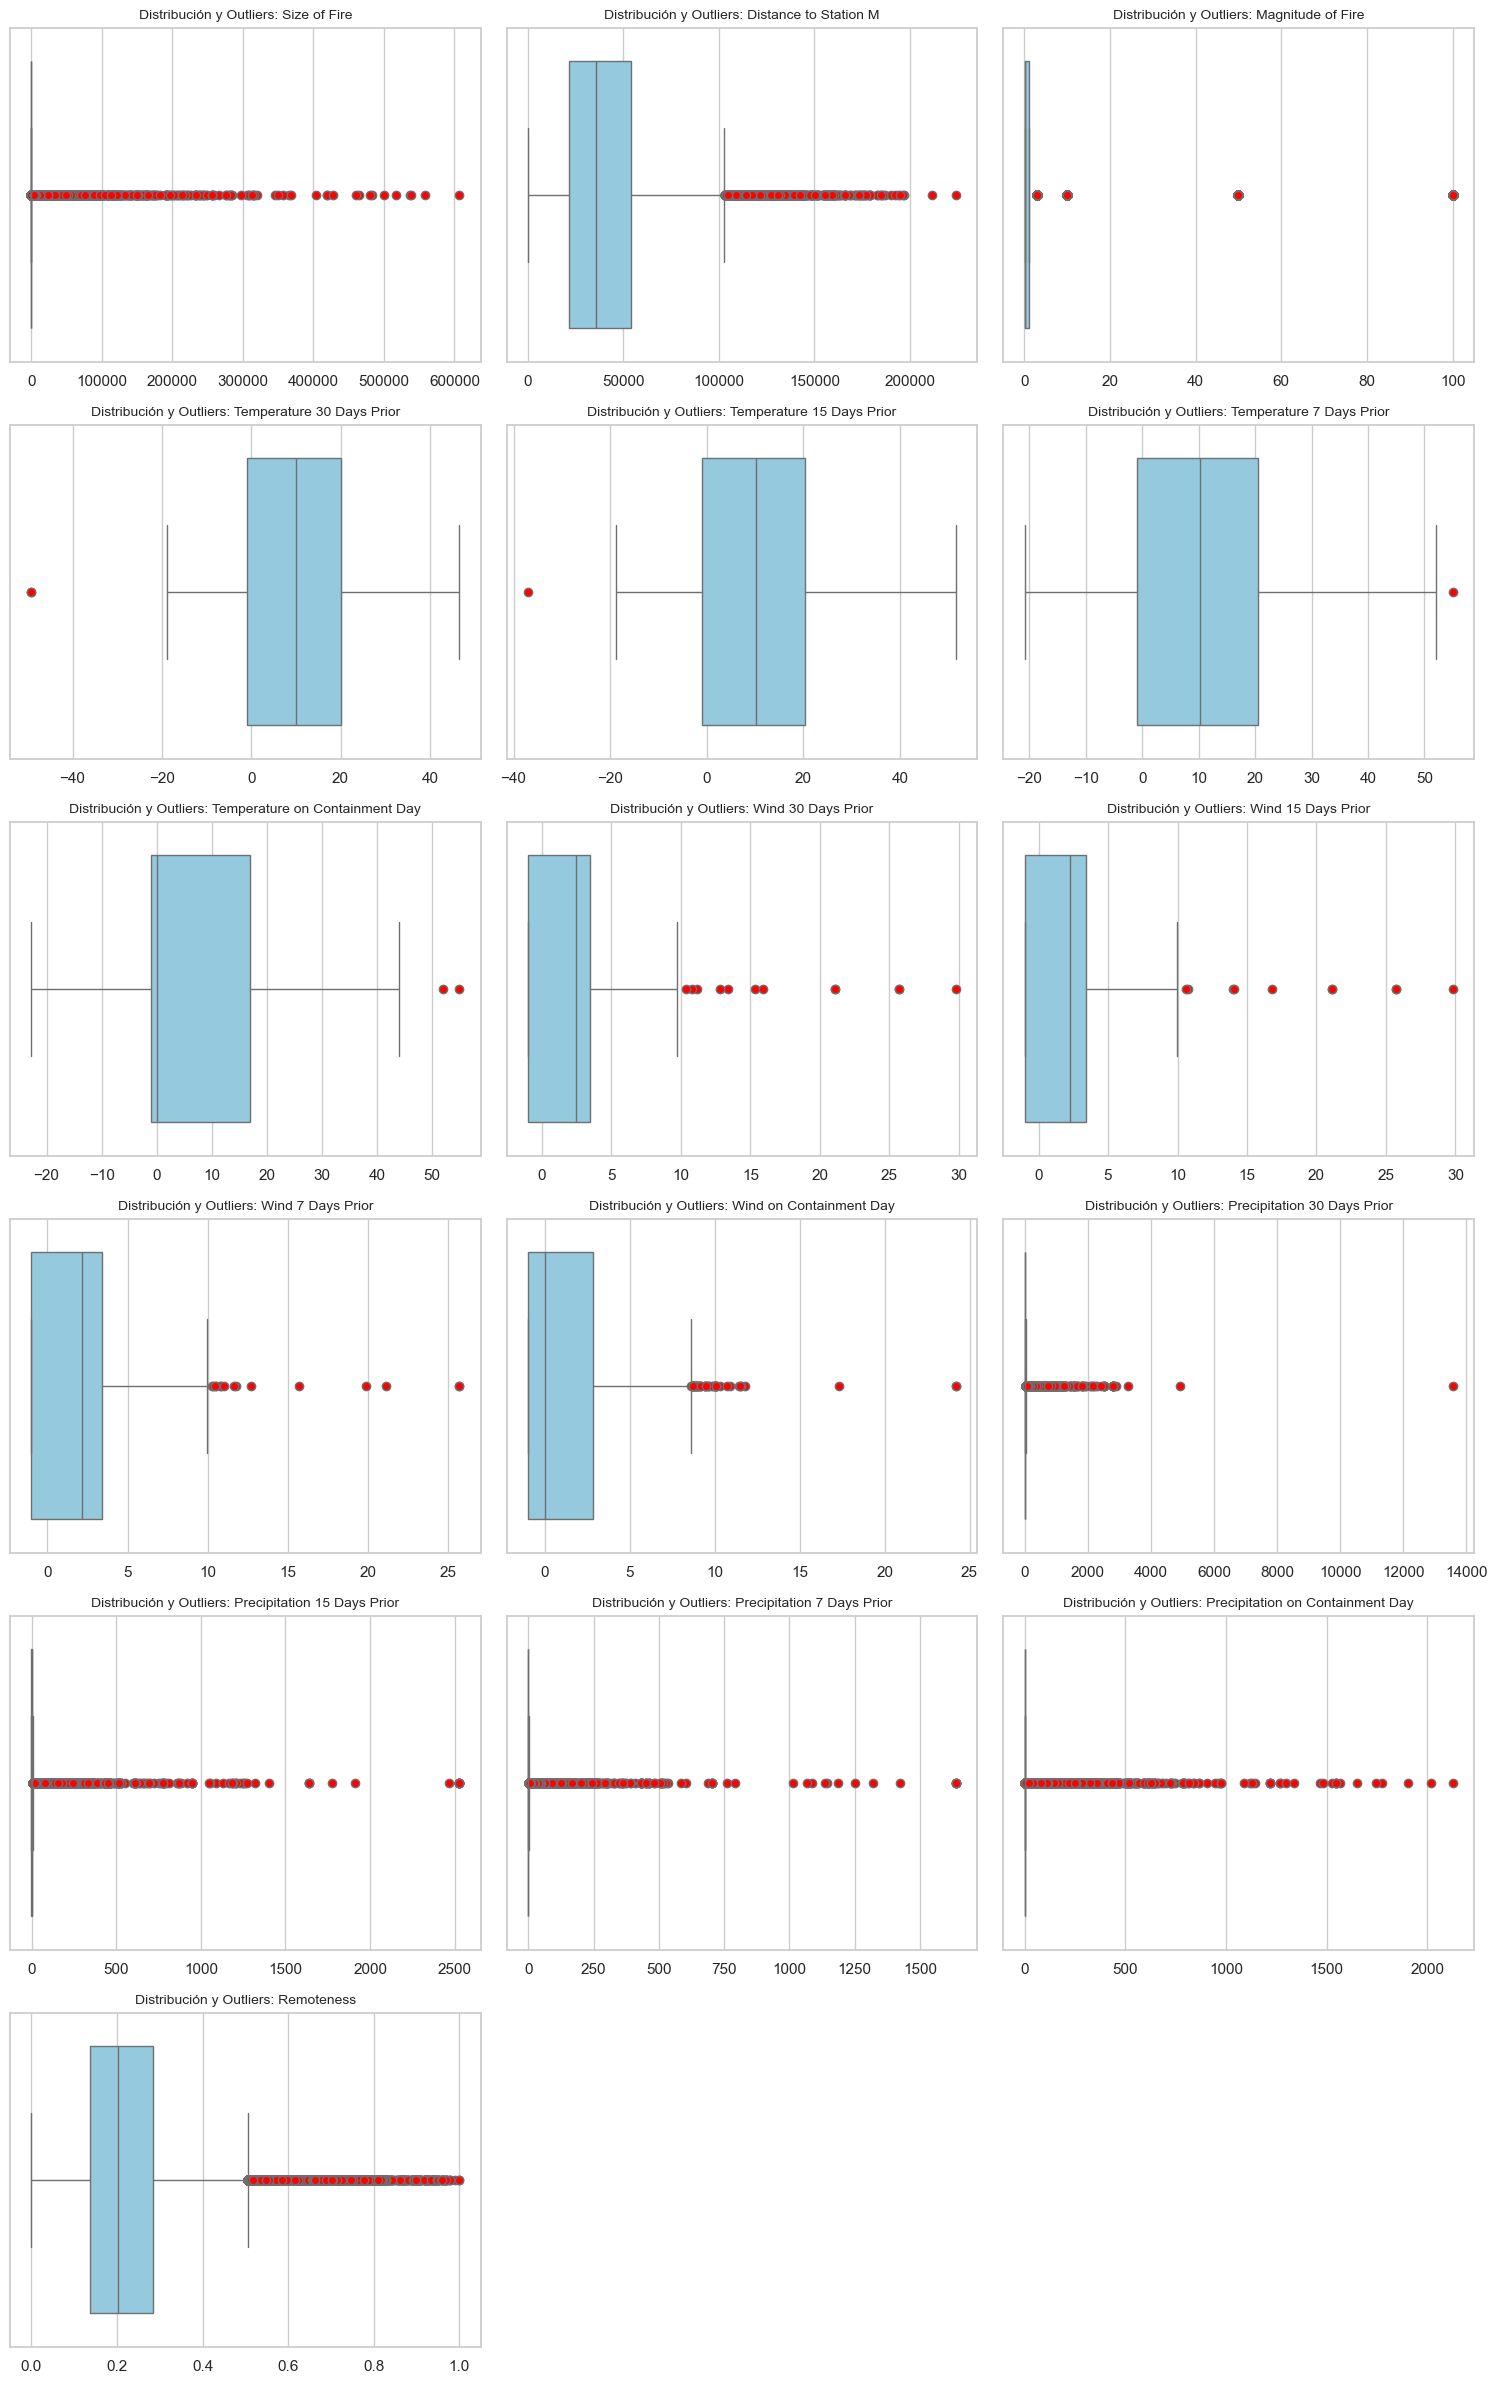

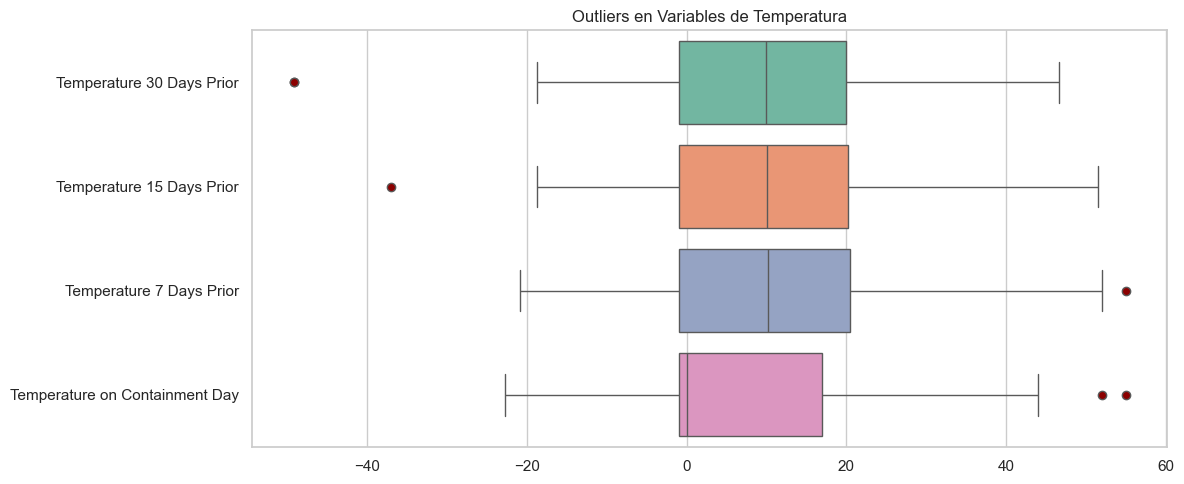

In [27]:
#El Z-score (puntuación Z) mide cuántas desviaciones estándar se aleja un dato de la media. Solo se aplica a columnas numéricas continuas (float64 o int64). Aplicarlo a texto, fechas o coordenadas de ubicación (como latitud/longitud) carece de sentido estadístico.

#########################################
# Paso 1: Seleccionar solo las columnas numéricas relevantes
#########################################

#Excluimos coordenadas y códigos/IDs (Year, WBAN, USAF, etc.) para calcular el Z-score únicamente en variables de medición (temperaturas, viento, humedad, precipitación, tamaño, etc.): 
import numpy as np
import pandas as pd
from scipy import stats

# 1. Seleccionar manualmente las variables numéricas de interés
numeric_cols = [
    "Size of Fire",
    "Distance to Station M",
    "Magnitude of Fire",
    "Temperature 30 Days Prior",
    "Temperature 15 Days Prior",
    "Temperature 7 Days Prior",
    "Temperature on Containment Day",
    "Wind 30 Days Prior",
    "Wind 15 Days Prior",
    "Wind 7 Days Prior",
    "Wind on Containment Day",
    "Humidity 30 Days Prior",
    "Humidity 15 Days Prior",
    "Humidity 7 Days Prior",
    "Humidity on Containment Day",
    "Precipitation 30 Days Prior",
    "Precipitation 15 Days Prior",
    "Precipitation 7 Days Prior",
    "Precipitation on Containment Day",
    "Remoteness",
]
#########################################
#Paso 2: Calcular el Z-score
#########################################
# El método stats.zscore ignora valores nulos si usamos nan_policy='omit'.
# z_scores = stats.zscore(df[numeric_cols], nan_policy='omit')
# abs_z_scores = np.abs(z_scores)
# outliers = (abs_z_scores > 3).all(axis=1)


# Crear un DataFrame con las puntuaciones Z de las columnas seleccionadas
z_scores = df[numeric_cols].apply(lambda x: stats.zscore(x, nan_policy="omit"))

# Opcional: Agregar sufijo '_zscore' y unir al DataFrame original
df_z = df.join(z_scores.add_suffix("_zscore"))

#########################################
# Paso 3: Usar el Z-score para filtrar Outliers (Valores atípicos)
#########################################
# Por regla general, un $\vert{}Z\vert{} > 3$ indica un valor atípico o extremo:
# outliers = (np.abs(z_scores) > 3).any(axis=1)
# df_outliers = df[outliers]
# Identificar filas que tengan al menos un outlier (|z| > 3) en las variables meteorológicas
threshold = 3
outliers = (np.abs(z_scores) > threshold).any(axis=1)

# Filtrar el DataFrame para eliminar los outliers
df_clean = df[~outliers]

print(f"Filas originales: {len(df)}")
print(f"Filas sin outliers: {len(df_clean)}")

#########################################
# 4. Contar outliers por columna
#########################################
# Cuenta cuántos registros superan el umbral (|Z| > 3) en cada columna
outliers_por_columna = (np.abs(z_scores) > threshold).sum()

# Mostrar únicamente las columnas que contienen al menos 1 outlier
columnas_con_outliers = outliers_por_columna[outliers_por_columna > 0]
print("Cantidad de outliers por columna:")
print(columnas_con_outliers)    

#########################################
# 5. Obtener el porcentaje de outliers respecto al total de datos
#########################################
# Calcula el porcentaje de filas afectadas en cada columna
porcentaje_outliers = (columnas_con_outliers / len(df)) * 100
print("\nPorcentaje de outliers por columna:")
print(porcentaje_outliers.round(2).astype(str) + "%")


#########################################
# 6. Extraer la lista con los nombres de las columnas afectadas
#########################################
# Guarda los nombres en una lista para usarlos en filtrados posteriores
lista_columnas_afectadas = columnas_con_outliers.index.tolist()
print("\nLista de columnas afectadas:")
print(lista_columnas_afectadas)

############################################
### 7. Visualización de Outliers con Seaborn
############################################
# Para visualizar los outliers de las columnas afectadas con Seaborn, puedes usar sns.boxplot(). Si tienes varias columnas, lo ideal es iterar sobre ellas para crear submarcos de gráfico (subplots) o representarlas juntas si tienen escalas similares.
# Opción 1: Un gráfico individual por cada columna (Recomendado)
# Dado que variables como Temperatura (°C/°F) y Size of Fire (acres/ha) tienen escalas totalmente distintas, es mejor dibujar un diagrama de caja independiente para cada columna afectada:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# Supongamos que 'lista_columnas_afectadas' proviene del paso anterior
n_cols = len(lista_columnas_afectadas)

# Crear una figura con una cuadrícula de subgráficos
fig, axes = plt.subplots(
    nrows=(n_cols + 2) // 3, ncols=3, figsize=(15, 4 * ((n_cols + 2) // 3))
)
axes = axes.flatten()

# Graficar un boxplot para cada columna con outliers
for i, col in enumerate(lista_columnas_afectadas):
    sns.boxplot(x=df[col], ax=axes[i], color="skyblue", flierprops={"markerfacecolor": "red", "marker": "o"})
    axes[i].set_title(f"Distribución y Outliers: {col}", fontsize=10)
    axes[i].set_xlabel("")

# Ocultar ejes vacíos si no se llena toda la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#Opción 2: Comparar variables con escalas similares (ej. Temperaturas)
# Si quieres comparar un grupo de variables que comparten la misma unidad de medida, puedes pasarlas directamente en un solo boxplot:
temp_cols = [
    "Temperature 30 Days Prior",
    "Temperature 15 Days Prior",
    "Temperature 7 Days Prior",
    "Temperature on Containment Day",
]

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df[temp_cols],
    orient="h",
    palette="Set2",
    flierprops={"markerfacecolor": "darkred"},
)
plt.title("Outliers en Variables de Temperatura")
plt.tight_layout()
plt.show()

# Qué observar en el Boxplot:
# Los puntos fuera de los "bigotes": Son los datos detectados como outliers según el Rango Intercuartílico ($IQR$).
# Relación con Z-Score: Aunque el Z-score asume una distribución normal y los boxplots usan percentiles ($Q1 - 1.5 \times IQR$),
#                los puntos dibujados en rojo/fuera de las líneas coincidirán estrechamente con los valores extremos que detectaste anteriormente.



# 5. Exploración visual de variables.


In [19]:
sns.set_theme()
# sns.relplot(
#         data=df[['Size of Fire', 'Cause of Fire']],
#           x="Size of Fire",
#             y="Cause of Fire",
#             hue="Cause of Fire",
#             kind="line" ,
#             col="Cause of Fire"                      
#             )

# 
#sns.pairplot(data=df, hue="Cause of Fire")

In [20]:
#sns.boxplot(x=df['HP'])

In [21]:
#sns.boxplot(x=df['Cylinders'])

In [22]:
#Q1 = df.quantile(0.25)
#Q3 = df.quantile(0.75)
#IQR = Q3 - Q1
#print(IQR)

Don't worry about the above values because it's not important to know each and every one of them because it's just important to know how to use this technique in order to remove the outliers.

In [23]:
#df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
#df.shape

As seen above there were around 1600 rows were outliers. But you cannot completely remove the outliers because even after you use the above technique there maybe 1–2 outlier unremoved but that ok because there were more than 100 outliers. Something is better than nothing.



---



## 9. Plot different features against one another (scatter), against frequency (histogram)

### Histogram

Histogram refers to the frequency of occurrence of variables in an interval. In this case, there are mainly 10 different types of car manufacturing companies, but it is often important to know who has the most number of cars. To do this histogram is one of the trivial solutions which lets us know the total number of car manufactured by a different company.

In [24]:
#df.Make.value_counts().nlargest(40).plot(kind='bar', figsize=(10,5))
#plt.title("Number of cars by make")
#plt.ylabel('Number of cars')
#plt.xlabel('Make');

### Heat Maps

Heat Maps is a type of plot which is necessary when we need to find the dependent variables. One of the best way to find the relationship between the features can be done using heat maps. In the below heat map we know that the price feature depends mainly on the Engine Size, Horsepower, and Cylinders.

In [25]:
#plt.figure(figsize=(10,5))
#c= df.corr()
#sns.heatmap(c,cmap="BrBG",annot=True)


### Scatterplot

We generally use scatter plots to find the correlation between two variables. Here the scatter plots are plotted between Horsepower and Price and we can see the plot below. With the plot given below, we can easily draw a trend line. These features provide a good scattering of points.

In [26]:
#fig, ax = plt.subplots(figsize=(10,6))
#ax.scatter(df['HP'], df['Price'])
#ax.set_xlabel('HP')
#ax.set_ylabel('Price')
#plt.show()